In [2]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data.csv
Saving data-dictionary.csv to data-dictionary.csv


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
print(df.shape)

df.info()

df.describe()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


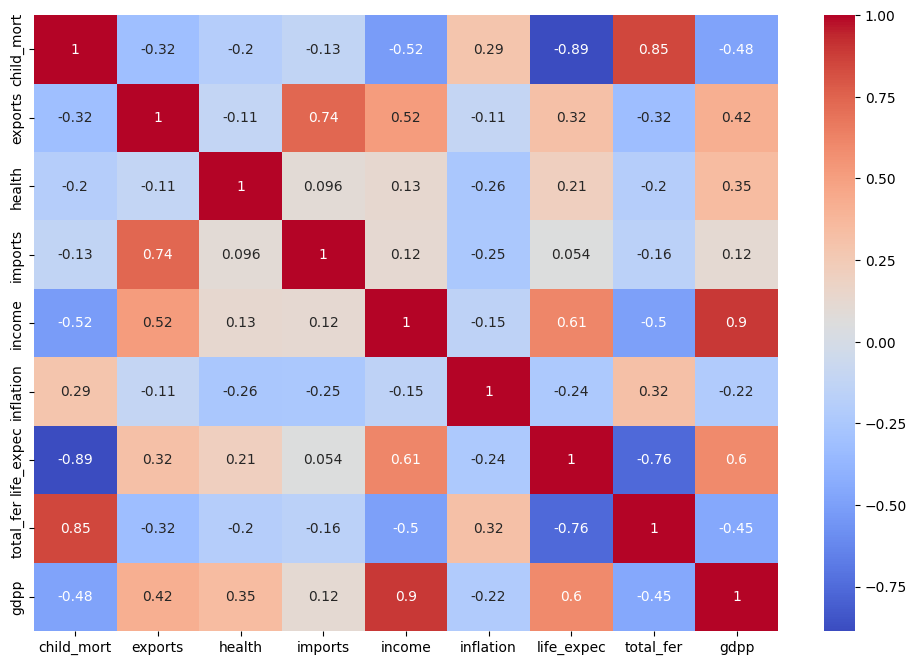

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [9]:
X = df.drop("country",axis=1)

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

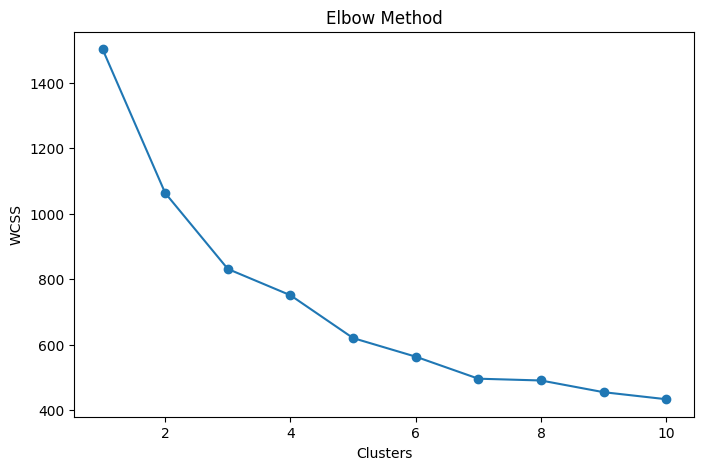

In [11]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

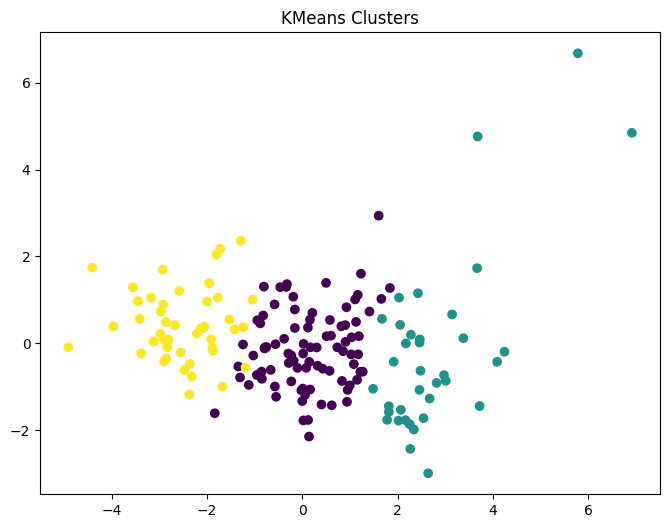

In [13]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['KMeans_Cluster'],
    cmap='viridis'
)

plt.title("KMeans Clusters")
plt.show()

In [14]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [15]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(
    X_scaled
)

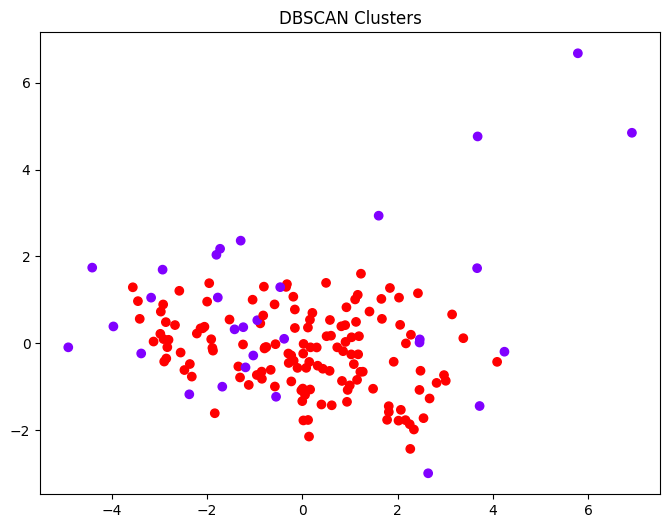

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['DBSCAN_Cluster'],
    cmap='rainbow'
)

plt.title("DBSCAN Clusters")

plt.show()

In [17]:
y = df['KMeans_Cluster']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [20]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [21]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        rf_acc,
        xgb_acc
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.285361
8,gdpp,0.218948
6,life_expec,0.172715
4,income,0.163631
7,total_fer,0.099650
2,health,0.022885
1,exports,0.013945
5,inflation,0.013046
3,imports,0.009818


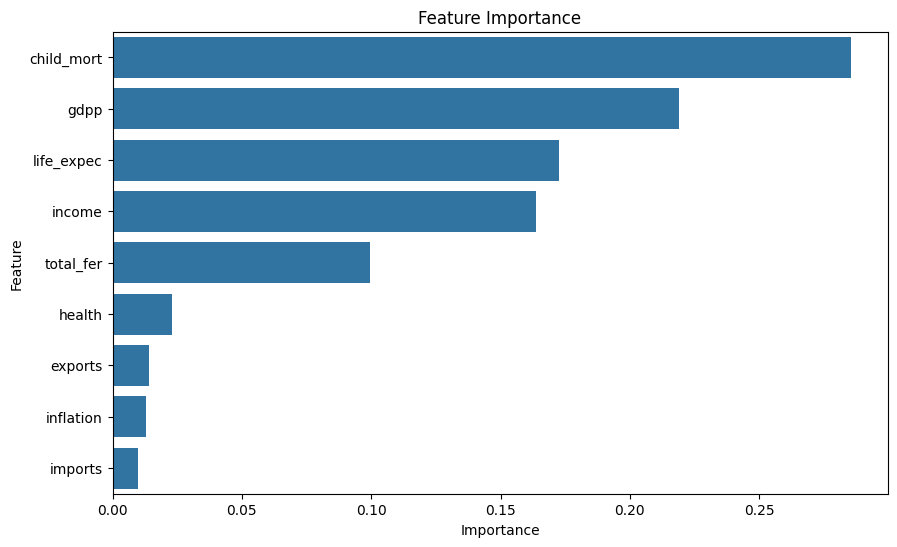

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

In [24]:
print("Country Intelligence Insights")

print("\n1. KMeans segmented countries into 3 groups.")

print("\n2. DBSCAN identified outlier nations.")

print("\n3. Random Forest and XGBoost successfully predicted country segments.")

print("\n4. Income, GDP, Child Mortality and Life Expectancy were key drivers.")

print("\n5. The system can assist NGOs and policy makers in prioritizing development efforts.")

Country Intelligence Insights

1. KMeans segmented countries into 3 groups.

2. DBSCAN identified outlier nations.

3. Random Forest and XGBoost successfully predicted country segments.

4. Income, GDP, Child Mortality and Life Expectancy were key drivers.

5. The system can assist NGOs and policy makers in prioritizing development efforts.
